# Set-up

In [11]:
import os
import sys
import torch
import pyfaidx
import numpy as np
import pandas as pd
import seaborn as sns

import seqpro as sp

from bpnetlite.bpnet import BPNet, CountWrapper
from tangermeme.io import extract_loci
from tangermeme.predict import predict

from matplotlib import pyplot as plt
import seaborn as sns; sns.set_style('white')

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

In [2]:
os.chdir("/cellar/users/aklie/projects/igvf/ChromBetaNet")

In [3]:
path_out = "scratch/2025_05_19"

# Load genome

In [4]:
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

In [5]:
genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load peaks

In [7]:
path_peaks = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/5_peak_analysis/peak_calls/rna_celltype+condition/12-1/snapatac2/SC.EC_control.narrowPeak"
path_schema = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/5_peak_analysis/peak_calls/rna_celltype+condition/12-1/snapatac2/SC.EC_control.narrowPeak.schema"
schema = pd.read_csv(path_schema, header=None, sep='\t')[0].tolist()  # convert schema to a list
peaks = pd.read_csv(path_peaks, header=None, sep='\t', names=schema)  # corrected to use schema

In [8]:
# Remove duplicate chrom start and end taking the highest q_value
peaks = peaks.sort_values('q_value', ascending=False).drop_duplicates(subset=['chrom', 'start', 'end'])
peaks

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak
10,chr1,633836,634204,.,1000,.,42.893456,29993.148438,29985.089844,195
3206,chr1,16644215,16645246,.,1000,.,20.894829,9765.295898,9758.180664,517
113152,chr17,64918889,64919978,.,1000,.,26.609274,9663.157227,9656.074219,642
106989,chr17,22521245,22521563,.,1000,.,40.503754,8967.622070,8960.691406,153
3192,chr1,16612717,16614051,.,1000,.,19.365326,8090.665527,8083.926270,884
...,...,...,...,...,...,...,...,...,...,...
1438,chr1,7472755,7472968,.,13,.,1.389377,2.693220,1.302138,95
20498,chr1,201610914,201611229,.,13,.,1.356132,2.693160,1.302081,102
135348,chr2,28745071,28745290,.,13,.,1.545330,2.692750,1.301688,105
128732,chr19,39062251,39062483,.,13,.,1.511487,2.692430,1.301395,109


# Load model

In [9]:
path_model = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.EC_control/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5"
model = BPNet.from_chrombpnet(path_model).cuda().eval()

In [10]:
count_wrapper = CountWrapper(model).cuda().eval()

# Load sequences

In [12]:
path_bw = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/4_integration/atac/pseudobulk/rna_celltype+condition/12-1/count_bws/SC.EC_control_unstranded.bw"

In [14]:
X, signals = extract_loci(
    loci=peaks,
    sequences=genome_fasta,
    signals=[path_bw],
)

ValueError: Encountered character that is not in `alphabet` or in `ignore`.

In [ ]:
y_0 = predict(
    model=count_wrapper,
    X=X,
    verbose=True,
)

100%|██████████| 431/431 [00:15<00:00, 27.00it/s]


In [ ]:
peaks_selected = peaks[peaks["chrom"] == "chr5"]

# Add the predicted counts to the peaks dataframe
peaks_selected["log_counts"] = torch.log(torch.sum(signals, dim=(1,2))).cpu().numpy()
peaks_selected["log_counts_pred"] = y_0[:, 0].cpu().numpy()

# Annote peaks as Enhancer_1, Enhancer_2, etc.
peaks_selected = peaks_selected.merge(isl1_enhancer_df[["peak_chrom", "peak_start", "peak_end"]], 
                                       left_on=["chrom", "start", "end"], 
                                       right_on=["peak_chrom", "peak_start", "peak_end"], 
                                       how="left", suffixes=("", "_enhancer"))
peaks_selected['enhancer_annotation'] = np.where(
    peaks_selected['peak_chrom'].notnull(),
    'Enhancer',
    np.nan
)
peaks_selected['enhancer_annotation'] = peaks_selected.groupby('chrom').cumcount() + 1
peaks_selected['enhancer_annotation'] = np.where(
    peaks_selected['peak_chrom'].notnull(),
    'Enhancer_' + peaks_selected['enhancer_annotation'].astype(str),
    np.nan
)

# Drop the temporary columns used for annotation
peaks_selected = peaks_selected.drop(columns=["peak_chrom", "peak_start", "peak_end"])
peaks_selected["enhancer_annotation"].value_counts()

/tmp/ipykernel_4185351/4148722850.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peaks_selected["log_counts"] = torch.log(torch.sum(signals, dim=(1,2))).cpu().numpy()
/tmp/ipykernel_4185351/4148722850.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peaks_selected["log_counts_pred"] = y_0[:, 0].cpu().numpy()


Enhancer_1523    1
Enhancer_3598    1
Enhancer_4010    1
Name: enhancer_annotation, dtype: int64

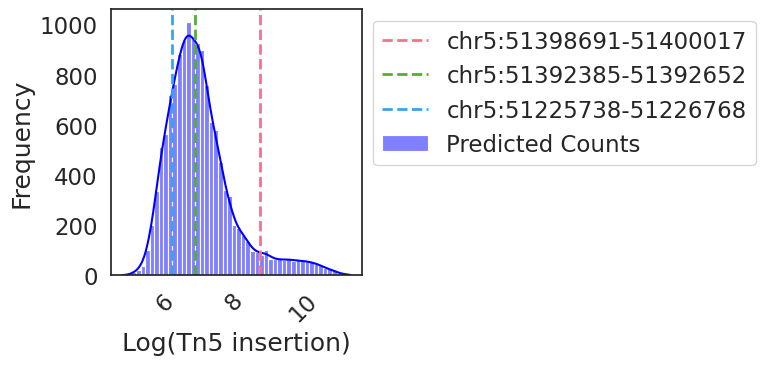

In [18]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1.5):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.histplot(
        peaks_selected["log_counts_pred"],
        bins=50,
        kde=True,
        color='blue',
        label='Predicted Counts',
        ax=ax
    )

    # Plot each ISL1 enhancer as a vertical line each with a different color
    enhancer_colors = sns.color_palette("husl", peaks_selected["enhancer_annotation"].nunique())
    for i, (enhancer_name, group) in enumerate(peaks_selected.groupby("enhancer_annotation")):
        if enhancer_name.startswith("Enhancer_"):
            enhancer_color = enhancer_colors[i % len(enhancer_colors)]
            #Grab chr:start-end for label
            locus = f"{group['chrom'].iloc[0]}:{group['start'].iloc[0]}-{group['end'].iloc[0]}"
            ax.axvline(
                x=group["log_counts_pred"].mean(),
                color=enhancer_color,
                linestyle='--',
                linewidth=2,
                label=locus
            )

    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()

# Enhancer ISM

In [19]:
sys.path.append(path_out)
from utils import greedy_ism

In [20]:
dtype = torch.float64

In [21]:
# Define model and ism params
seq_len = 2114
target_len = 1000
ism_window = 500
plot_window = 200

# Seq limits
seq_center = 2114 // 2
seq_start = seq_center - ism_window // 2
seq_end = seq_center + ism_window // 2

# Target limits
target_center = 1000 // 2
target_start = target_center - ism_window // 2
target_end = target_center + ism_window // 2

# Plot starts
plot_seq_center = 1050
plot_seq_start = seq_center - plot_window // 2
plot_seq_end = seq_center + plot_window // 2
plot_target_center = 500
plot_target_start = target_center - plot_window // 2
plot_target_end = target_center + plot_window // 2

print(f"seq_start: {seq_start}, seq_end: {seq_end}")
print(f"target_start: {target_start}, target_end: {target_end}")
print(f"plot_seq_start: {plot_seq_start}, plot_seq_end: {plot_seq_end}")
print(f"plot_target_start: {plot_target_start}, plot_target_end: {plot_target_end}")

seq_start: 807, seq_end: 1307
target_start: 250, target_end: 750
plot_seq_start: 957, plot_seq_end: 1157
plot_target_start: 400, plot_target_end: 600


In [22]:
peaks_selected[peaks_selected["enhancer_annotation"].notnull()]

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak,log_counts,log_counts_pred,enhancer_annotation
1522,chr5,51398691,51400017,.,1000,.,5.414588,572.279907,569.810364,757,8.606851,8.739220,Enhancer_1523
3597,chr5,51392385,51392652,.,1000,.,2.563179,115.003090,112.938934,116,7.406104,6.867933,Enhancer_3598
4009,chr5,51225738,51226768,.,869,.,5.166846,88.994141,86.981285,852,6.481577,6.220936,Enhancer_4010


In [23]:
X_optimized = []

## Enhancer #1

In [24]:
enahncer_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].iloc[0]
idx_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].index[0]
chrom_ = enahncer_["chrom"]
start_ = enahncer_["start"]
end_ = enahncer_["end"]
preds = peaks_selected["log_counts_pred"].values[idx_]
print(f"Processing enhancer: {chrom_}:{start_}-{end_}: {preds}")

Processing enhancer: chr5:51398691-51400017: 8.739219665527344


In [25]:
plot_coordinate_start = start_ - plot_window // 2
plot_coordinate_end = end_ + plot_window // 2
print(f"Plotting coordinates: {chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

Plotting coordinates: chr5:51398591-51400117


In [26]:
X_ = X[idx_:idx_+1]
X_.shape

torch.Size([1, 4, 2114])

In [27]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [28]:
predict(
    model=count_wrapper,
    X=X_,
    verbose=True,   
)

100%|██████████| 1/1 [00:00<00:00,  9.45it/s]


tensor([[8.7396]])

In [29]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
)

Iteration 0/10 - y_hat: 8.740
Iteration 1/10 - y_hat: 9.332
Iteration 2/10 - y_hat: 9.779
Iteration 3/10 - y_hat: 10.136
Iteration 4/10 - y_hat: 10.462
Iteration 5/10 - y_hat: 10.762
Iteration 6/10 - y_hat: 11.014
Iteration 7/10 - y_hat: 11.204
Iteration 8/10 - y_hat: 11.369
Iteration 9/10 - y_hat: 11.516
Iteration 10/10 - y_hat: 11.637


In [30]:
# Get attribution scores for the original sequence
X_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_.shape

100%|██████████| 20/20 [00:28<00:00,  1.43s/it]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

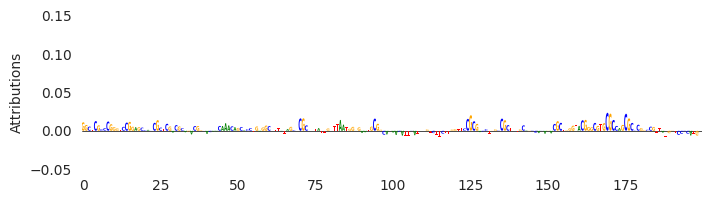

In [31]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [32]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.21it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

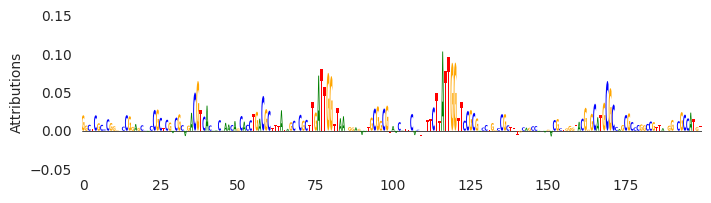

In [33]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [34]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(995, 'G', 'T'),
 (1015, 'G', 'C'),
 (1032, 'T', 'G'),
 (1037, 'T', 'G'),
 (1055, 'A', 'G'),
 (1065, 'T', 'C'),
 (1068, 'G', 'T'),
 (1073, 'C', 'A'),
 (1123, 'G', 'A'),
 (1150, 'C', 'G')]

In [35]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 6247.227892592328
mutated counts: 113190.7832434986


((1000,), (1000,))

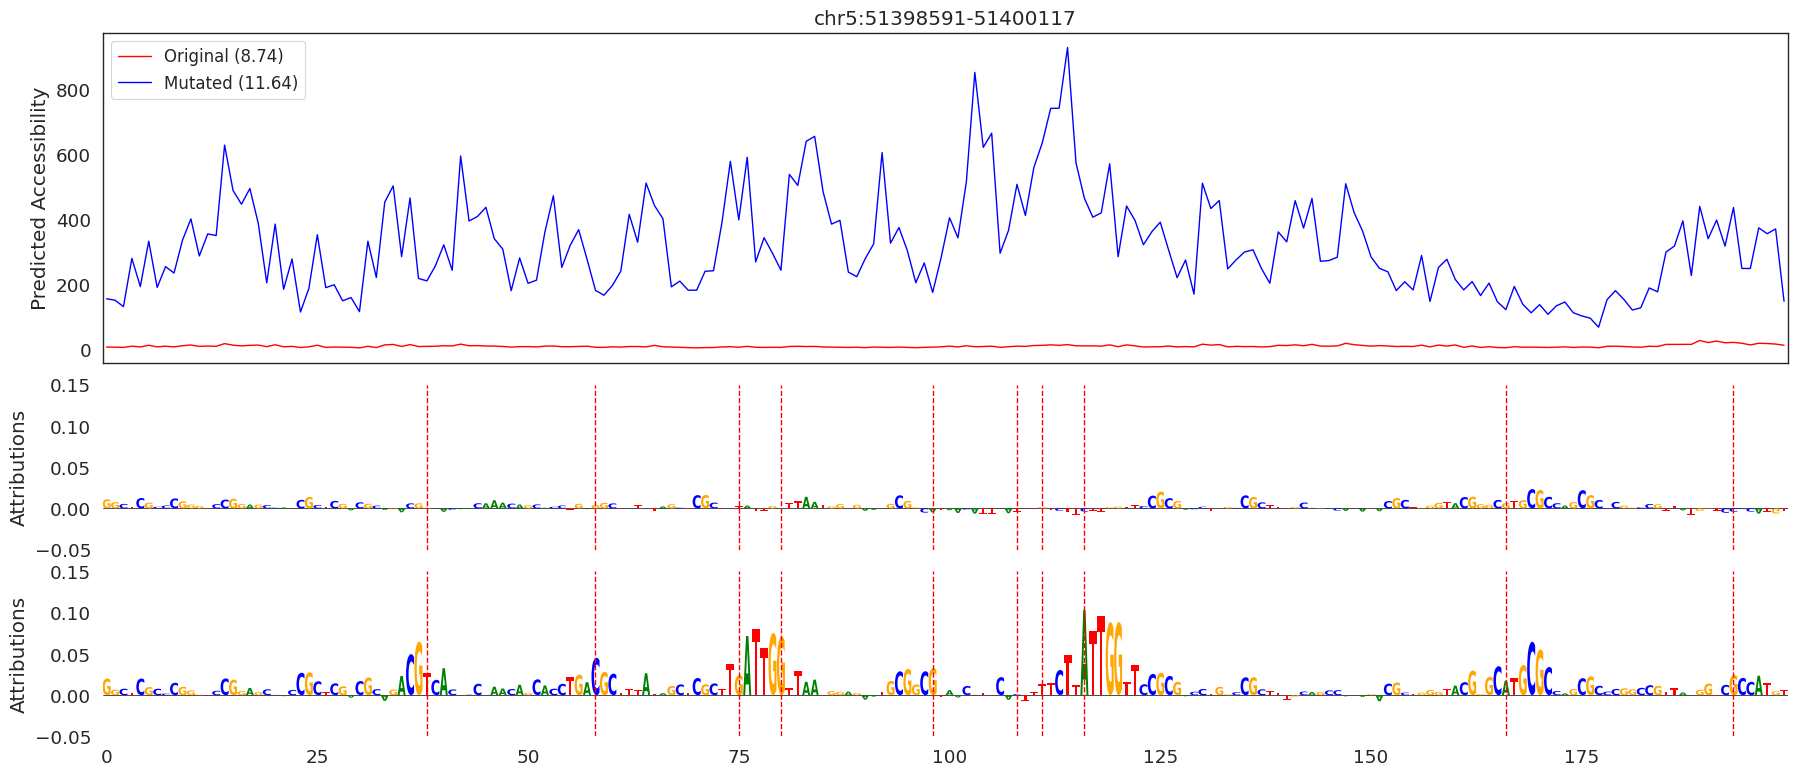

In [36]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [37]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [38]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,NFYB_HUMAN.H11MO.0.A,1068,1084,0.716186,0.002488
1,NDF1_HUMAN.H11MO.0.A,821,835,-0.016942,0.009901
2,HOXB3_MA0903.1,1027,1044,0.548500,0.019851
3,NRF1_MA0506.1,1119,1133,0.352417,0.036176


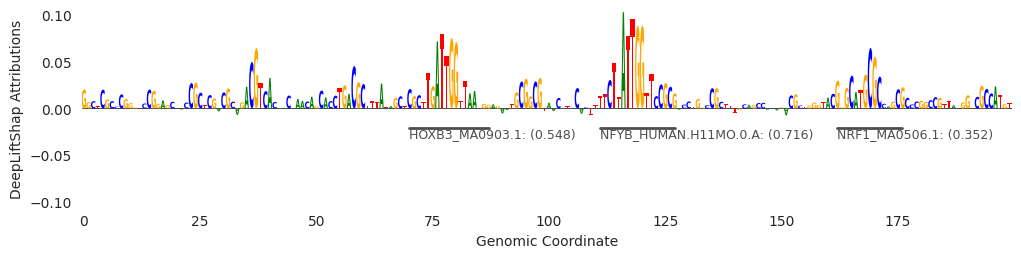

In [39]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

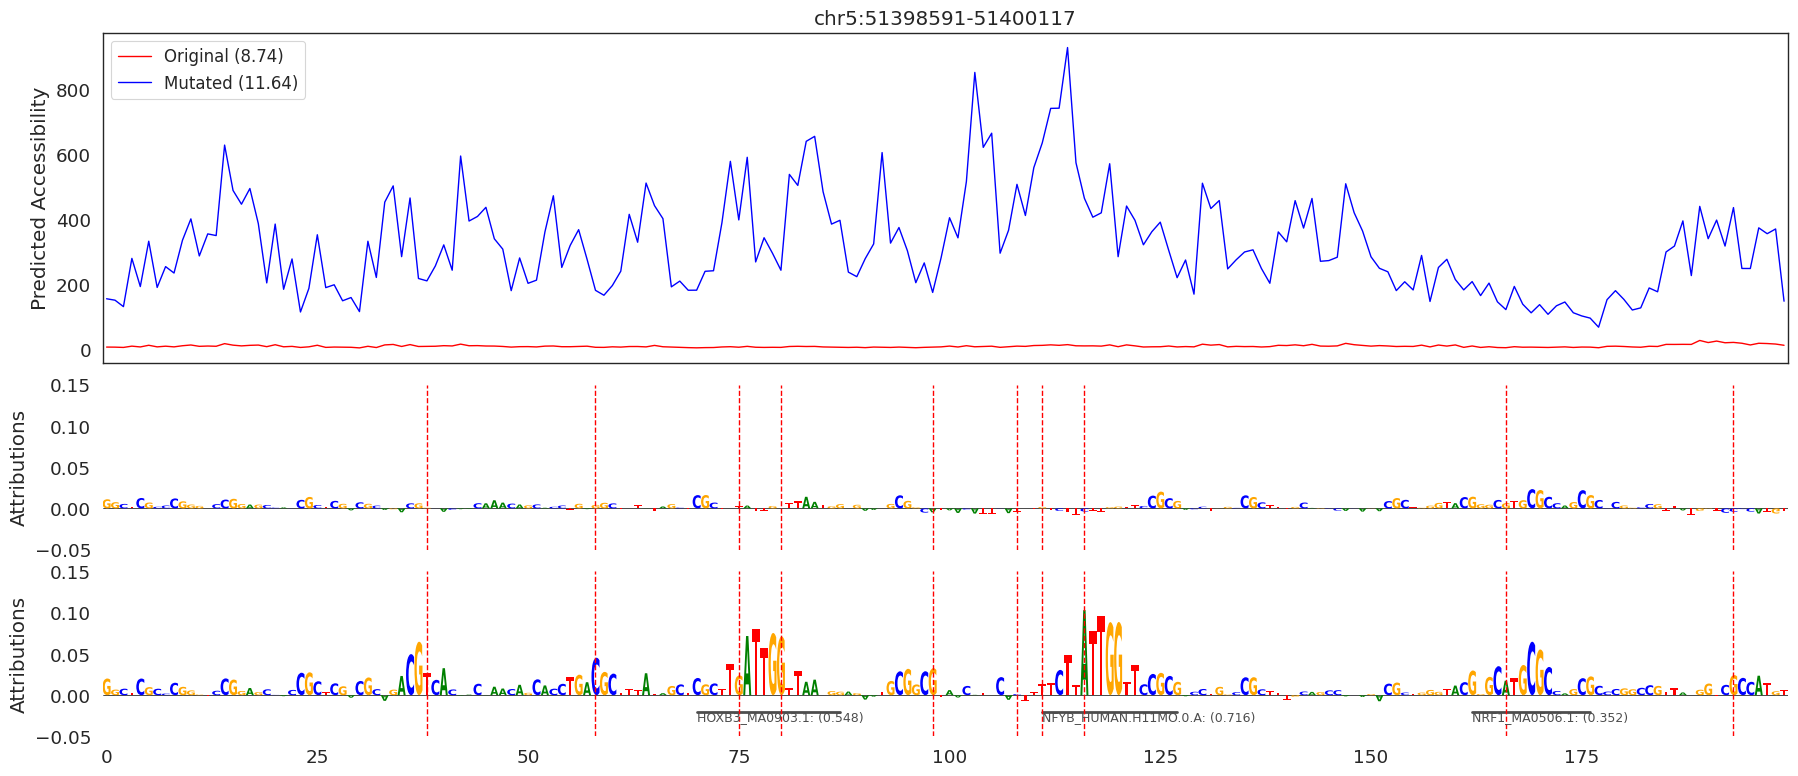

In [40]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start, end=plot_seq_end, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [41]:
X_optimized.append([chrom_, start_, end_, predict(model=count_wrapper, X=X_greedy_, verbose=True)[0].cpu().detach().numpy()])

100%|██████████| 1/1 [00:00<00:00, 73.05it/s]


## Enhancer #2

In [42]:
enahncer_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].iloc[1]
idx_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].index[1]
chrom_ = enahncer_["chrom"]
start_ = enahncer_["start"]
end_ = enahncer_["end"]
preds = peaks_selected["log_counts_pred"].values[idx_]
print(f"Processing enhancer: {chrom_}:{start_}-{end_}: {preds}")

Processing enhancer: chr5:51392385-51392652: 6.8679327964782715


In [43]:
plot_coordinate_start = start_ - plot_window // 2
plot_coordinate_end = end_ + plot_window // 2
print(f"Plotting coordinates: {chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

Plotting coordinates: chr5:51392285-51392752


In [44]:
X_ = X[idx_:idx_+1]
X_.shape

torch.Size([1, 4, 2114])

In [45]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [46]:
predict(
    model=count_wrapper,
    X=X_,
    verbose=True,   
)

100%|██████████| 1/1 [00:00<00:00, 335.87it/s]


tensor([[6.8685]])

In [47]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
)

Iteration 0/10 - y_hat: 6.868
Iteration 1/10 - y_hat: 7.362
Iteration 2/10 - y_hat: 7.962
Iteration 3/10 - y_hat: 8.441
Iteration 4/10 - y_hat: 8.869
Iteration 5/10 - y_hat: 9.450
Iteration 6/10 - y_hat: 9.884
Iteration 7/10 - y_hat: 10.276
Iteration 8/10 - y_hat: 10.604
Iteration 9/10 - y_hat: 10.882
Iteration 10/10 - y_hat: 11.116


In [48]:
# Get attribution scores for the original sequence
X_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.26it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

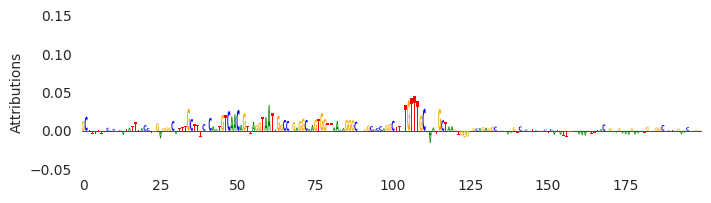

In [49]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [ ]:
o

100%|██████████| 20/20 [00:00<00:00, 26.15it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

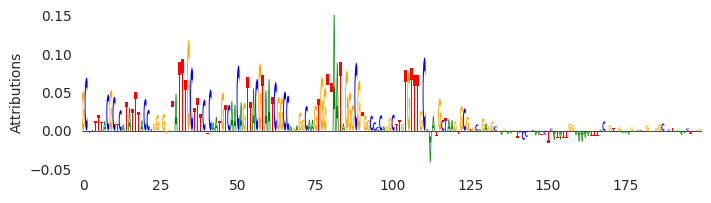

In [51]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [52]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(943, 'T', 'G'),
 (948, 'T', 'A'),
 (955, 'T', 'C'),
 (966, 'C', 'G'),
 (986, 'C', 'T'),
 (1013, 'G', 'C'),
 (1019, 'T', 'C'),
 (1040, 'A', 'T'),
 (1046, 'T', 'G'),
 (1080, 'G', 'C')]

In [53]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 961.2482280934236
mutated counts: 67320.28653847908


((1000,), (1000,))

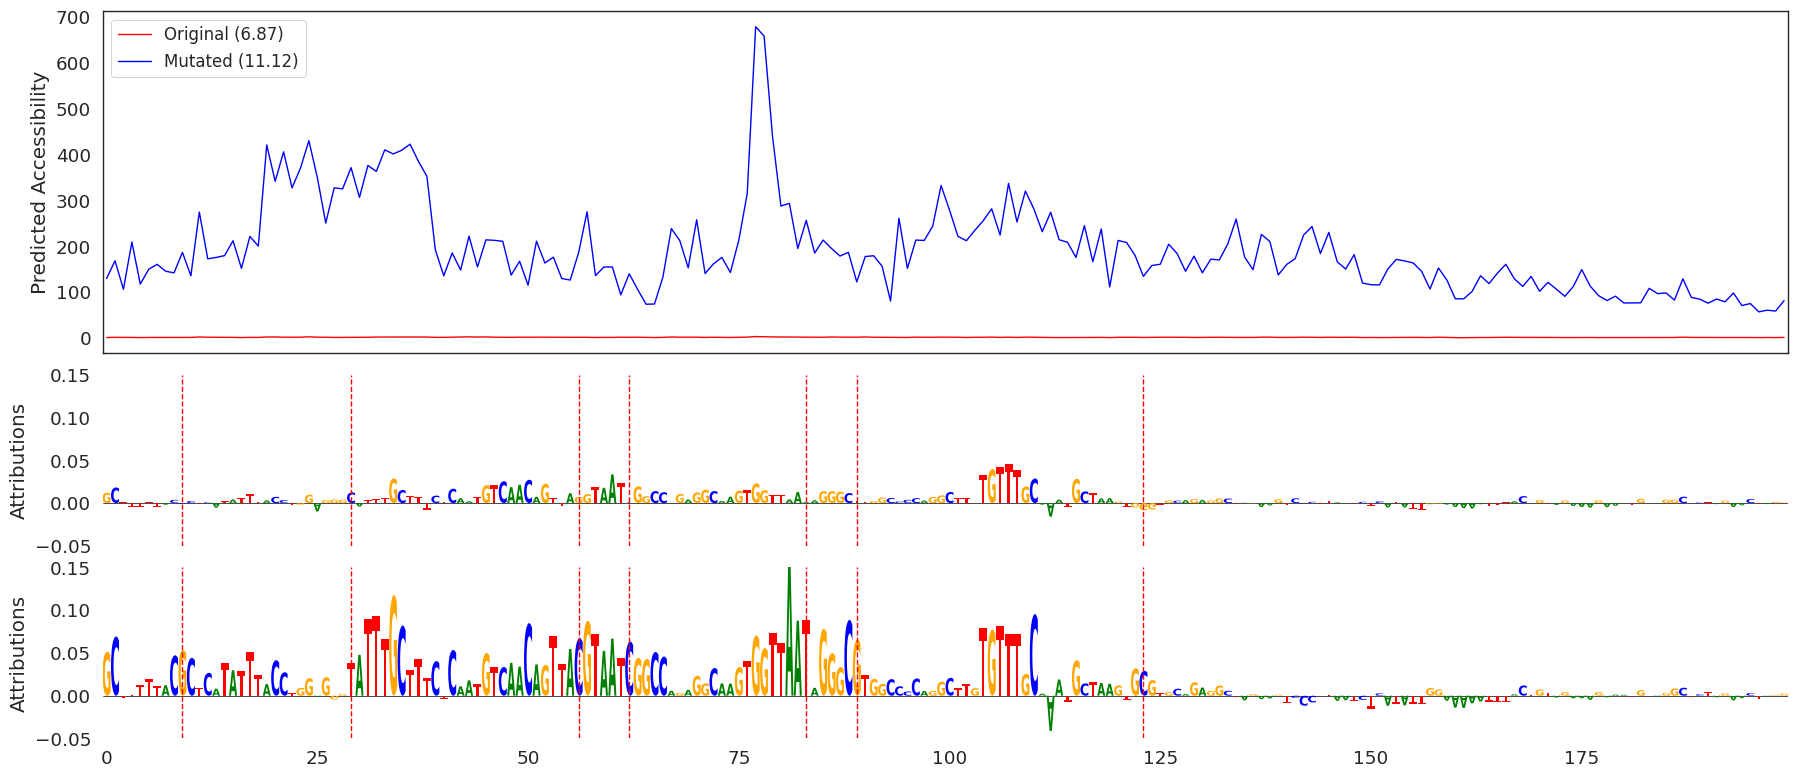

In [54]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    #axes[0].set_title(f"{chrom}:{ref_start}-{ref_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [55]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [56]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,FOXA2_HUMAN.H11MO.0.A,983,998,0.684657,0.011594
1,HOXB3_MA0903.1,1030,1046,0.956503,0.011765
2,ETV6_MOUSE.H11MO.0.C,922,938,0.051006,0.012821
3,FOXA2_HUMAN.H11MO.0.A,1056,1070,0.534920,0.023188
4,FOSB+JUN_MA1127.1,1007,1022,0.859927,0.037681


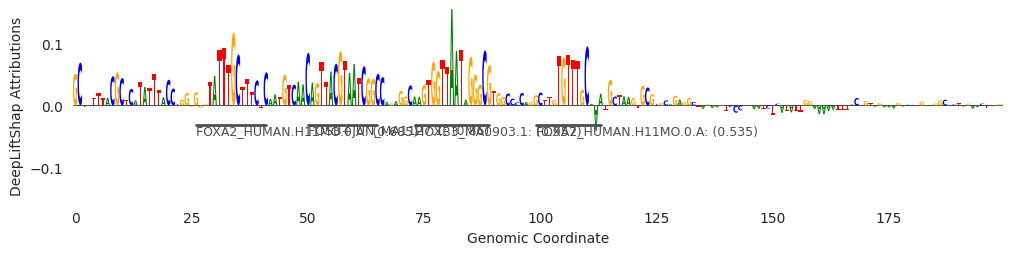

In [57]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

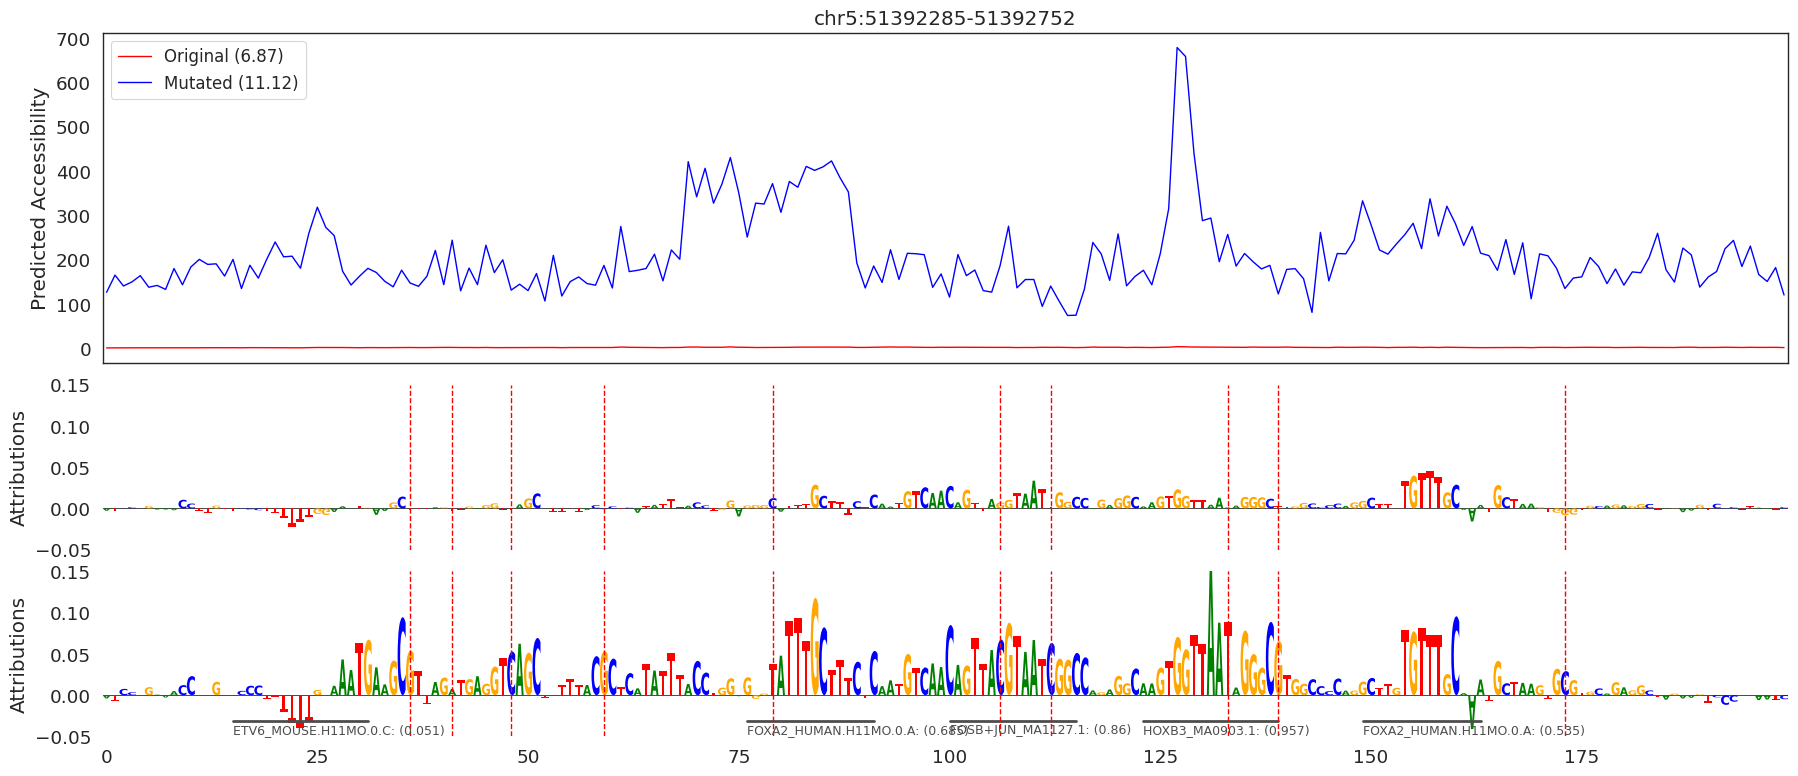

In [58]:
offset = -50

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [59]:
X_optimized.append([chrom_, start_, end_, predict(model=count_wrapper, X=X_greedy_, verbose=True)[0].cpu().detach().numpy()])

100%|██████████| 1/1 [00:00<00:00, 72.56it/s]


## Enhancer #3

In [60]:
enahncer_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].iloc[2]
idx_ = peaks_selected[peaks_selected["enhancer_annotation"].notnull()].index[2]
chrom_ = enahncer_["chrom"]
start_ = enahncer_["start"]
end_ = enahncer_["end"]
preds = peaks_selected["log_counts_pred"].values[idx_]
print(f"Processing enhancer: {chrom_}:{start_}-{end_}: {preds}")

Processing enhancer: chr5:51225738-51226768: 6.220935821533203


In [61]:
plot_coordinate_start = start_ - plot_window // 2
plot_coordinate_end = end_ + plot_window // 2
print(f"Plotting coordinates: {chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

Plotting coordinates: chr5:51225638-51226868


In [62]:
X_ = X[idx_:idx_+1]
X_.shape

torch.Size([1, 4, 2114])

In [63]:
count_wrapper.type(torch.float32)

CountWrapper(
  (model): BPNet(
    (iconv): Conv1d(4, 512, kernel_size=(21,), stride=(1,), padding=(10,))
    (irelu): ReLU()
    (rconvs): ModuleList(
      (0): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (1): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (2): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
      (3): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
      (4): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(32,), dilation=(32,))
      (5): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(64,), dilation=(64,))
      (6): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(128,), dilation=(128,))
      (7): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=(256,), dilation=(256,))
    )
    (rrelus): ModuleList(
      (0-7): 8 x ReLU()
    )
    (fconv): Conv1d(512, 1, kernel_size=(75,), stride=(1,), padding

In [64]:
predict(
    model=count_wrapper,
    X=X_,
    verbose=True,   
)

100%|██████████| 1/1 [00:00<00:00, 328.14it/s]


tensor([[6.2210]])

In [65]:
X_greedy_ = greedy_ism(
    count_wrapper,
    X_,
    seq_len=seq_len,
    ism_window=ism_window,
    k=1,
    max_iter=10,
    verbose=True,
)

Iteration 0/10 - y_hat: 6.221
Iteration 1/10 - y_hat: 6.950
Iteration 2/10 - y_hat: 7.420
Iteration 3/10 - y_hat: 7.825
Iteration 4/10 - y_hat: 8.298
Iteration 5/10 - y_hat: 8.623
Iteration 6/10 - y_hat: 9.066
Iteration 7/10 - y_hat: 9.502
Iteration 8/10 - y_hat: 9.888
Iteration 9/10 - y_hat: 10.204
Iteration 10/10 - y_hat: 10.476


In [66]:
# Get attribution scores for the original sequence
X_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.10it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

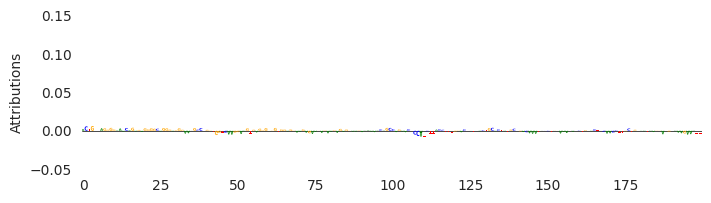

In [67]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [68]:
# Get attribution scores for the original sequence
X_greedy_attr_ = deep_lift_shap(
    count_wrapper.type(dtype), 
    X=X_greedy_.type(dtype),
    n_shuffles=20,
    batch_size=16,
    verbose=True,
    warning_threshold=1e-4
)
X_greedy_attr_.shape

100%|██████████| 20/20 [00:00<00:00, 27.03it/s]


torch.Size([1, 4, 2114])

(-0.05, 0.15)

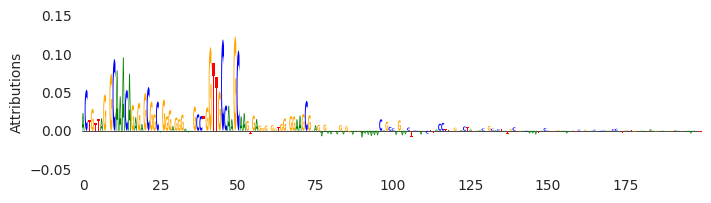

In [69]:
# Second plot: Sequence attributions for allele 1
fig, ax = plt.subplots(figsize=(8, 2))
plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=ax)  # Assuming plot_logo works with axes
ax.set_ylabel("Attributions")
ax.set_ylim(-0.05, 0.15)

In [70]:
# Find all the differences between the original and mutated sequences, both the change and the position
original_seq = sp.decode_ohe(X_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
original_seq = b''.join(original_seq[0]).decode('utf-8')
mutated_seq = sp.decode_ohe(X_greedy_.cpu().numpy().astype(np.uint8), alphabet=sp.DNA, ohe_axis=1)
mutated_seq = b''.join(mutated_seq[0]).decode('utf-8')
diffs = [(i, original_seq[i], mutated_seq[i]) for i in range(len(original_seq)) if original_seq[i] != mutated_seq[i]]
diffs

[(921, 'T', 'A'),
 (926, 'C', 'G'),
 (929, 'T', 'G'),
 (956, 'C', 'A'),
 (967, 'G', 'C'),
 (978, 'G', 'C'),
 (1000, 'G', 'T'),
 (1002, 'T', 'C'),
 (1007, 'G', 'C'),
 (1029, 'A', 'C')]

In [71]:
original_profile, original_counts = predict(model, X_)
original_counts = np.squeeze(np.exp(original_counts.cpu().detach().numpy()))
original_profile = np.squeeze(torch.exp(log_softmax_profile(original_profile)).cpu().detach().numpy())

mutated_profile, mutated_counts = predict(model, X_greedy_)
mutated_counts = np.squeeze(np.exp(mutated_counts.cpu().detach().numpy()))
mutated_profile = np.squeeze(torch.exp(log_softmax_profile(mutated_profile)).cpu().detach().numpy())

print(f"original counts: {original_counts}")
print(f"mutated counts: {mutated_counts}")

original_pred = original_counts * original_profile
mutated_pred = mutated_counts * mutated_profile
original_pred.shape, mutated_pred.shape

original counts: 503.3919397174102
mutated counts: 35470.08211600825


((1000,), (1000,))

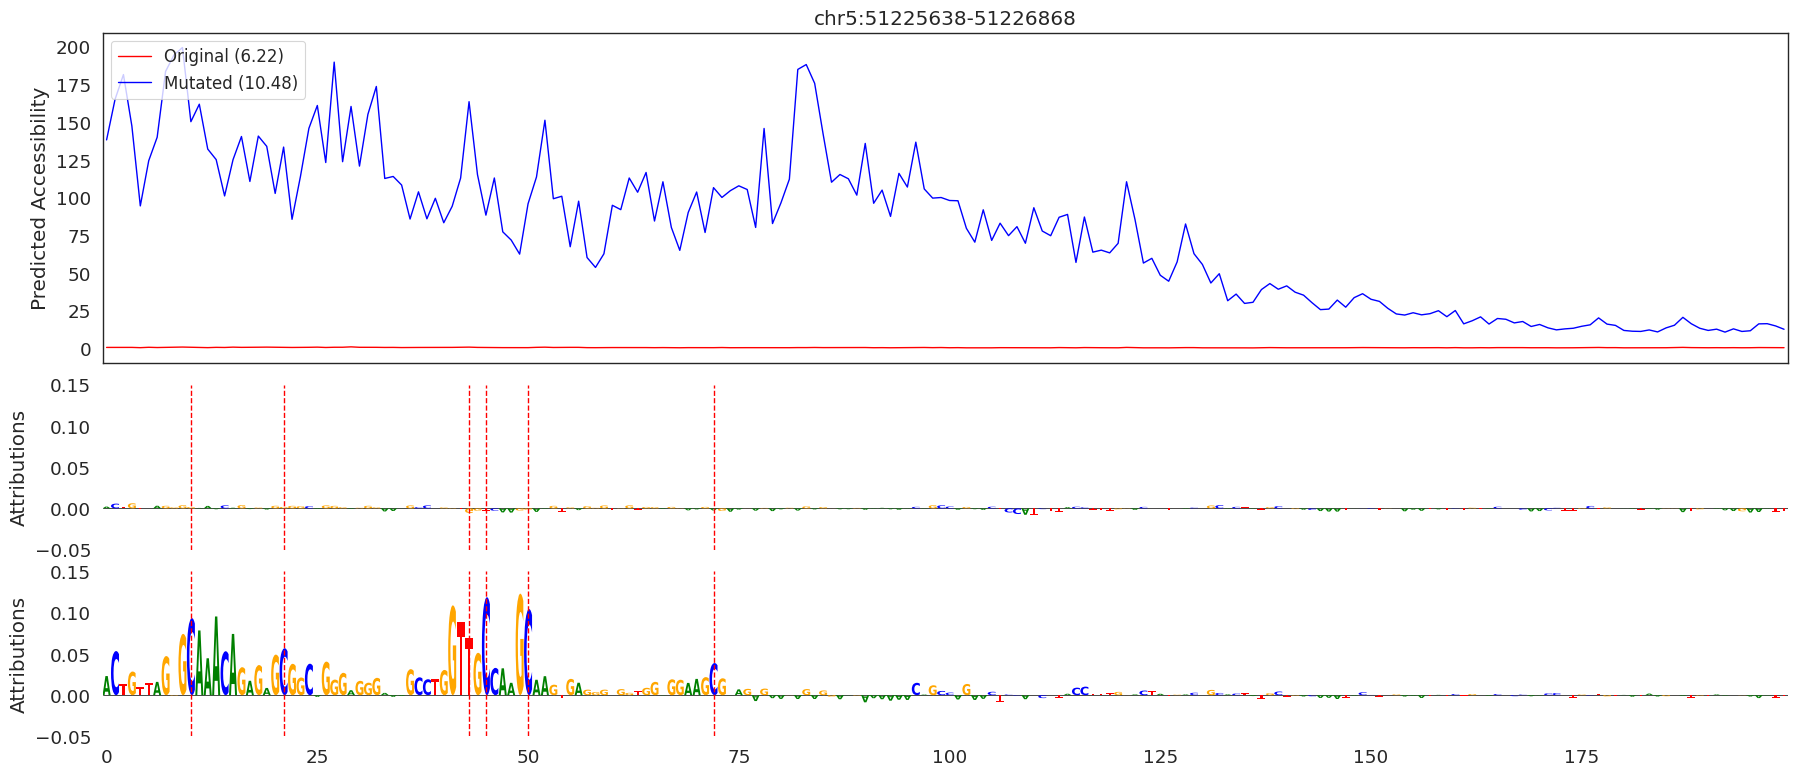

In [72]:
with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start:plot_target_end], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start:plot_target_end], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[1])  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0, :, plot_seq_start:plot_seq_end], ax=axes[2])  # Assuming plot_logo works with axes
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()

In [73]:
greedy_seqlets = recursive_seqlets(X_greedy_attr_[:, :, seq_start:seq_end].sum(dim=1), threshold=0.05, additional_flanks=5)
motif_idxs = annotate_seqlets(X_greedy_[:, :, seq_start:seq_end], greedy_seqlets, "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype_250k/motifs/meme/combined.meme")[0][:, 0]
greedy_seqlets['start'] += seq_start
greedy_seqlets['end'] += seq_start

In [74]:
greedy_seqlets["example_idx"] = motif_id_mp.loc[motif_names[motif_idxs]].values
greedy_seqlets.head()

,example_idx,start,end,attribution,p-value
0,ZNF384_MA1125.1,886,900,-0.039839,-1.110223e-15
1,RFX4_RFX_2,993,1007,0.762467,2.898551e-03
2,FOXA2_HUMAN.H11MO.0.A,912,927,0.781129,8.695652e-03
3,FOXA2_HUMAN.H11MO.0.A,962,976,0.678956,1.453488e-02
4,HNF4A_MOUSE.H11MO.0.A,868,882,-0.042578,3.311258e-02


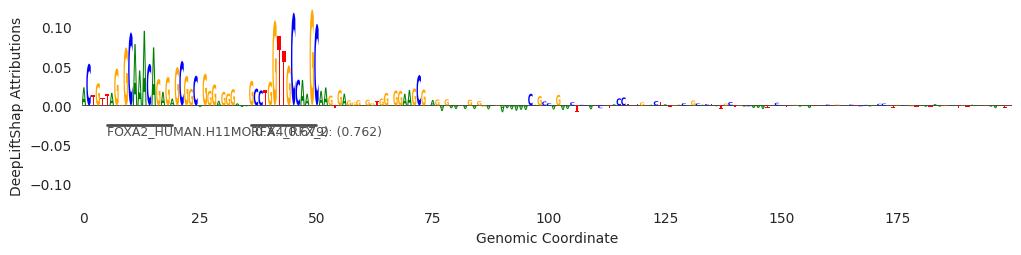

In [75]:
plt.figure(figsize=(12, 2.5))
ax = plt.subplot(111)
plot_logo(X_greedy_attr_[0], ax=ax, start=plot_seq_start, end=plot_seq_end, annotations=greedy_seqlets, score_key='attribution', n_tracks=2)
plt.ylabel("DeepLiftShap Attributions")
plt.xlabel("Genomic Coordinate")
plt.show()

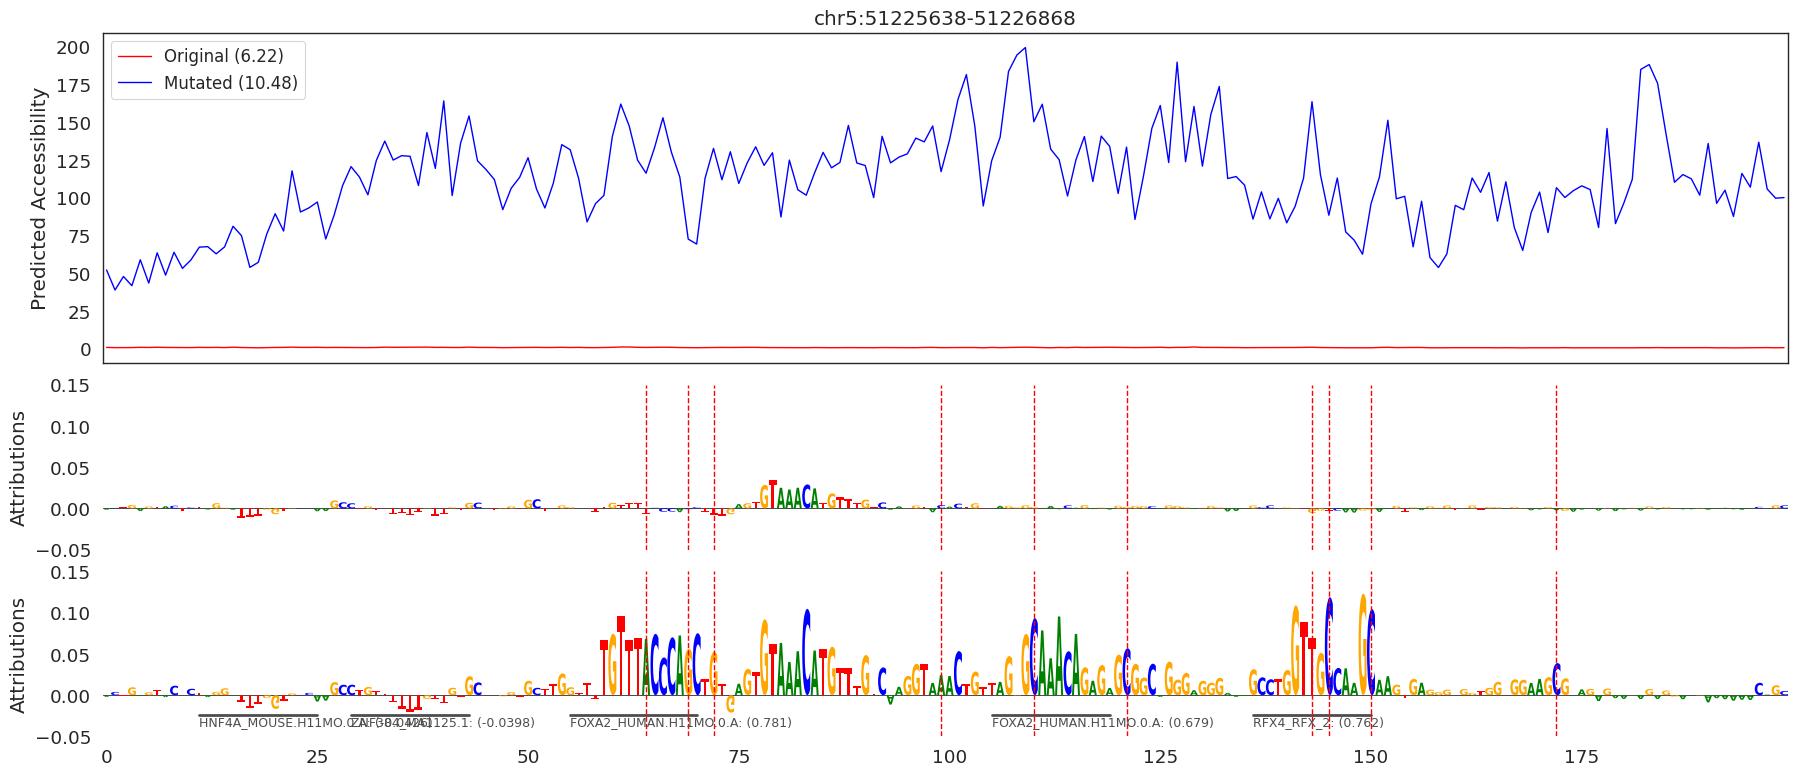

In [76]:
offset = -100

with sns.plotting_context("paper", font_scale=1.5):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(18, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})

    # First plot: Predictions before variant inclusion
    axes[0].plot(range(0, plot_window), original_pred[plot_target_start+offset:plot_target_end+offset], color='r', linewidth=1, label=f"Original ({round(float(np.log(original_counts)), 2)})")
    axes[0].plot(range(0, plot_window), mutated_pred[plot_target_start+offset:plot_target_end+offset], color='b', linewidth=1, label=f"Mutated ({round(float(np.log(mutated_counts)), 2)})")
    axes[0].set_ylabel("Predicted Accessibility")
    axes[0].legend(fontsize=12, loc="upper left")
    axes[0].set_title(f"{chrom_}:{plot_coordinate_start}-{plot_coordinate_end}")

    # Second plot: Sequence attributions for allele 1
    plot_logo(X_attr_[0], ax=axes[1], start=plot_seq_start + offset, end=plot_seq_end + offset)  # Assuming plot_logo works with axes
    axes[1].set_ylabel("Attributions")
    axes[1].set_ylim(-0.05, 0.15)

    # Third plot: Sequence attributions for allele 2
    plot_logo(X_greedy_attr_[0], ax=axes[2], start=plot_seq_start + offset, end=plot_seq_end + offset, annotations=greedy_seqlets, score_key='attribution', n_tracks=4)
    axes[2].set_ylabel("Attributions")
    axes[2].set_ylim(-0.05, 0.15)

    # Add in the mutation positions as vertical red lines
    for diff in diffs:
        pos = diff[0]

        # need to correct for distance from start
        plot_pos = pos - plot_seq_start - offset
        axes[1].axvline(plot_pos, color='r', linestyle='--', linewidth=1)
        axes[2].axvline(plot_pos, color='r', linestyle='--', linewidth=1)

    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, f"ISL1_ism_{chrom_}_{start_}-{end_}.pdf"), bbox_inches='tight', dpi=300)

In [77]:
X_optimized.append([chrom_, start_, end_, predict(model=count_wrapper, X=X_greedy_, verbose=True)[0].cpu().detach().numpy()])

100%|██████████| 1/1 [00:00<00:00, 72.50it/s]


# 2nd Histogram

In [78]:
optimized_df = pd.DataFrame(X_optimized, columns=["chrom", "start", "end", "optimized_counts"])
optimized_df["optimized_counts"] = optimized_df["optimized_counts"].apply(lambda x: x[0])
optimized_df

,chrom,start,end,optimized_counts
0,chr5,51398691,51400017,11.636830
1,chr5,51392385,51392652,11.117217
2,chr5,51225738,51226768,10.476445


In [79]:
# Add optimized counts for 
peaks_selected = peaks_selected.merge(optimized_df, how='left', on=["chrom", "start", "end"])
peaks_selected

,chrom,start,end,name,score,strand,signal_value,p_value,q_value,peak,log_counts,log_counts_pred,enhancer_annotation,optimized_counts
0,chr5,41903823,41904671,.,1000,.,24.401741,12328.777344,12322.569336,389,10.104836,10.777331,NaN,NaN
1,chr5,115544309,115545185,.,1000,.,23.402042,12028.393555,12022.332031,545,10.057495,10.353184,NaN,NaN
2,chr5,176646851,176647833,.,1000,.,19.345003,11610.129883,11604.316406,463,10.171031,10.467952,NaN,NaN
3,chr5,149551034,149552035,.,1000,.,22.170277,11314.760742,11309.133789,492,9.993145,11.146877,NaN,NaN
4,chr5,783889,785719,.,1000,.,16.959793,10962.878906,10957.493164,923,10.153545,10.345690,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13775,chr5,180469636,180469871,.,13,.,1.335979,2.680410,1.363804,93,5.916202,6.556131,NaN,NaN
13776,chr5,16914213,16914573,.,13,.,1.363918,2.679570,1.363010,175,5.971262,6.215029,NaN,NaN
13777,chr5,150056385,150056625,.,13,.,1.284528,2.654210,1.338758,93,6.251904,6.894413,NaN,NaN
13778,chr5,178330724,178330970,.,13,.,1.411860,2.646640,1.331526,99,5.703783,7.279574,NaN,NaN


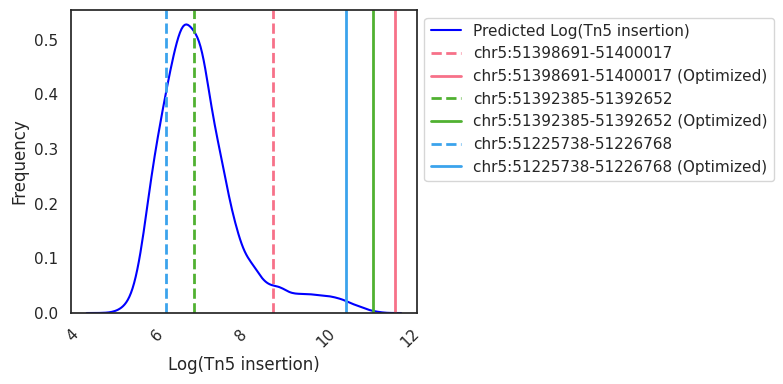

In [80]:
# Plot a beautiful histogram of the predictions 
with sns.plotting_context("notebook", font_scale=1):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot forward
    sns.kdeplot(
        peaks_selected["log_counts_pred"],
        color='blue',
        label='Predicted Log(Tn5 insertion)',
        ax=ax
    )

    # Plot each ISL1 enhancer as a vertical line each with a different color
    enhancer_colors = sns.color_palette("husl", peaks_selected["enhancer_annotation"].nunique())
    for i, (enhancer_name, group) in enumerate(peaks_selected.groupby("enhancer_annotation")):
        if enhancer_name.startswith("Enhancer_"):
            enhancer_color = enhancer_colors[i % len(enhancer_colors)]
            locus = f"{group['chrom'].iloc[0]}:{group['start'].iloc[0]}-{group['end'].iloc[0]}"

            # unoptimized enhancer
            ax.axvline(
                x=group["log_counts_pred"].mean(),
                color=enhancer_color,
                linestyle='--',
                linewidth=2,
                label=locus
            )

            # optimized enhancer
            if not group["optimized_counts"].isnull().all():
                ax.axvline(
                    x=group["optimized_counts"].mean(),
                    color=enhancer_color,
                    linestyle='-',
                    linewidth=2,
                    label=f"{locus} (Optimized)"
                )

        # Also plot the predicted counts for the optimized enhancer
    # Move legend outside of the plot
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xlabel('Log(Tn5 insertion)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)

    # 
    plt.tight_layout()
    #plt.savefig(os.path.join(path_out, "ISL1_enhancer_predictions_histogram.pdf"), bbox_inches='tight', dpi=300)

In [ ]:
peaks_selected.to_csv("ISL1_enhancer_predictions.csv", index=False)

Exception ignored in atexit callback: <bound method InteractiveShell.atexit_operations of <ipykernel.zmqshell.ZMQInteractiveShell object at 0x15555114cd50>>
Traceback (most recent call last):
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3952, in atexit_operations
    self._atexit_once()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3935, in _atexit_once
    self.history_manager.end_session()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/IPython/core/history.py", line 592, in end_session
    self.writeout_cache()
  File "/cellar/users/aklie/opt/miniconda3/envs/eugene_tools/lib/python3.11/site-packages/decorator.py", line 232, in fun
    return caller(func, *(extras + args), **kw)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/cellar/users/aklie/opt/miniconda3/envs/eug

# DONE!

---